# week-6 DEMO 
- NAME: Riya Agrawal

- SECTION: PF

- REG NO.:251090052030

- ROLL NO.:46

- TOPIC: Demo 6: Data Visualization: context, effective visuals and storytelling


In [ ]:
STEP 1- UNDERSTANDING THE DATASET BEFORE PLOTTING

In [3]:
    import pandas as pd
    df=pd.read_csv("StudentsPerformance.csv")
    df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


SELECTING ROWS/COLUMNS USING .loc(LET SELECT USING LABELS) AND .iloc(LETS SELECT USING INDEX)

In [11]:
df.loc[:,["math score","reading score","writing score"]].head()

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [15]:
df.loc[df["test preparation course"]=="completed",["math score","reading score","writing score"]]

,math score,reading score,writing score
1,69,90,88
6,88,95,92
8,64,64,67
13,78,72,70
18,46,42,46
...,...,...,...
990,86,81,75
991,65,82,78
995,88,99,95
997,59,71,65


In [13]:
print(df.iloc[0:5,:])

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [17]:
 print(df.iloc[0:5,-1:])

   writing score
0             74
1             88
2             93
3             44
4             75


STEP 2: UNDERSTANDING STRUCTURE OF DATA

In [18]:
df.shape

(1000, 8)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [22]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


HANDLING MISSING VALUES FROM THE DATA 

In [23]:
import numpy as np
df_miss=df.copy()
df_miss.loc[0,"math score"]=np.nan
df_miss.loc[5,"reading score"]=np.nan
df_miss.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     1
reading score                  1
writing score                  0
dtype: int64

In [24]:
df_drop=df_miss.dropna()
print("before drop:",df_miss.shape)
print("after drop:",df_drop.shape)

before drop: (1000, 8)
after drop: (998, 8)


STEP 3: SUMMARIZE THE DATA  BEFORE PLOTTING

In [ ]:
DF[["math score","reading score"]]

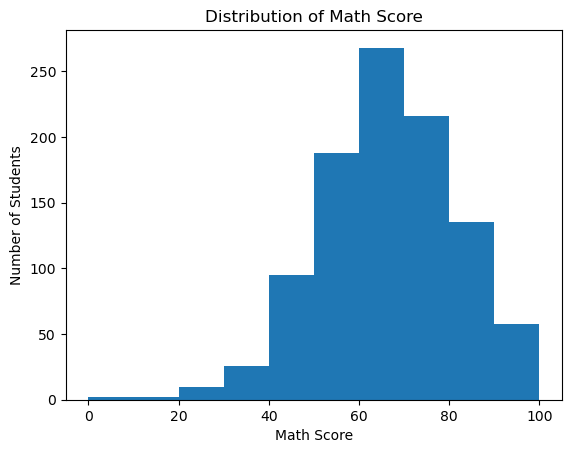

In [35]:
import matplotlib.pyplot as plt
plt.hist(df['math score'],bins=10)
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Math Score")
plt.show()

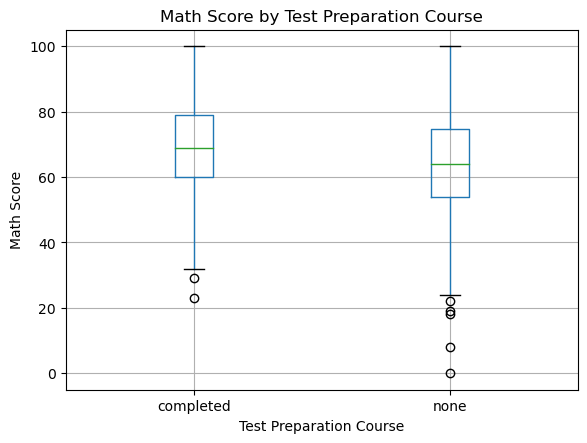

In [32]:
df.boxplot(column='math score',by='test preparation course')
plt.title("Math Score by Test Preparation Course")
plt.suptitle("")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")
plt.show()

In [44]:
Q1=df['math score'].quantile(0.25)
Q2=df['math score'].quantile(0.75)
IQR=Q2-Q1
lower=Q1-1.5*IQR
upper=Q2+1.5*IQR
outliers=df[(df['math score']<lower) | (df['math score']>upper)]
print("Outlier count",outliers.shape[0])
outliers[['math score','reading score','writing score']].head()

Outlier count 8


,math score,reading score,writing score
17,18,32,28
59,0,17,10
145,22,39,33
338,24,38,27
466,26,31,38


In [45]:
df_no_out=df[(df["math score"]>=lower)&(df["math score"]<=upper)]
print("Original :",df.shape,"\nafter removing outliers:",df_no_out.shape)

Original : (1000, 8) 
after removing outliers: (992, 8)


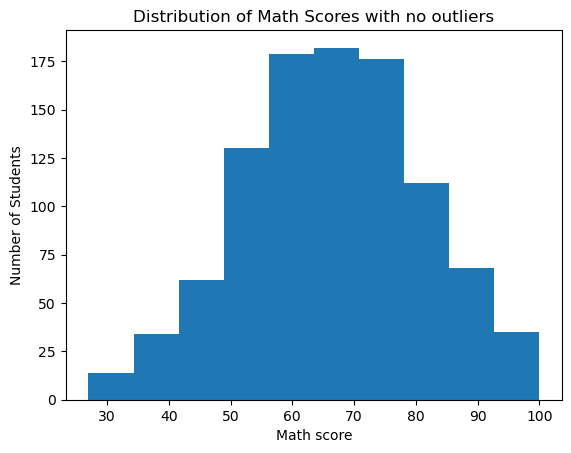

In [46]:
plt.hist(df_no_out['math score'],bins=10)
plt.xlabel("Math score")
plt.ylabel("Number of Students")
plt.title("Distribution of Math Scores with no outliers")
plt.show()

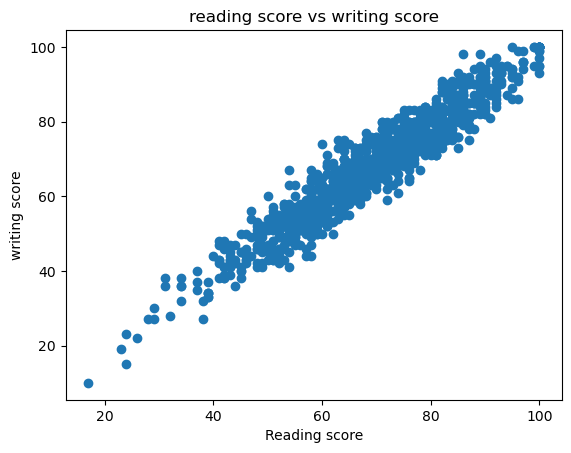

In [47]:
plt.scatter(df["reading score"],df["writing score"])
plt.xlabel("Reading score")
plt.ylabel("writing score")
plt.title("reading score vs writing score")
plt.show()